# Notebook 1 — Data Ingestion & Preprocessing
## PS6: Chart Pattern Intelligence | ET AI Hackathon 2026

**What this notebook does:**
- Installs required packages
- Downloads 2 years of OHLCV data for Nifty 500 stocks via yfinance
- Cleans & normalizes data
- Generates candlestick chart images (input for CNN in Notebook 2)
- Saves everything as Parquet for fast reload



In [10]:
# Step 1: Install all required packages
# Run this cell once
import subprocess, sys
packages = [
    'yfinance', 'pandas', 'numpy', 'matplotlib',
    'mplfinance', 'scikit-learn', 'scipy', 'plotly',
    'anthropic', 'streamlit', 'fastparquet', 'pyarrow',
    'torch', 'torchvision', 'pillow', 'opencv-python'
]
for pkg in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
print('All packages installed successfully.')

All packages installed successfully.


In [2]:
# Step 2: Imports
import yfinance as yf
import pandas as pd
import numpy as np
import mplfinance as mpf
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Directory setup
BASE_DIR = Path('ps6_data')
OHLCV_DIR = BASE_DIR / 'ohlcv'
CHART_DIR = BASE_DIR / 'charts'
for d in [OHLCV_DIR, CHART_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print('Directories ready:', BASE_DIR)

Directories ready: ps6_data


In [3]:
# Step 3: Define stock universe
# Using a representative set of liquid NSE stocks for hackathon demo
# In production, use the full Nifty 500 list

NIFTY50_SYMBOLS = [
    'RELIANCE.NS', 'TCS.NS', 'HDFCBANK.NS', 'INFY.NS', 'ICICIBANK.NS',
    'HINDUNILVR.NS', 'ITC.NS', 'SBIN.NS', 'BHARTIARTL.NS', 'KOTAKBANK.NS',
    'LT.NS', 'HCLTECH.NS', 'ASIANPAINT.NS', 'AXISBANK.NS', 'WIPRO.NS',
    'BAJFINANCE.NS', 'MARUTI.NS', 'SUNPHARMA.NS', 'TITAN.NS', 'ULTRACEMCO.NS',
    'NESTLEIND.NS', 'POWERGRID.NS', 'TECHM.NS', 'NTPC.NS', 'ADANIENT.NS',
    'ONGC.NS', 'BAJAJFINSV.NS', 'JSWSTEEL.NS', 'TATASTEEL.NS', 'DRREDDY.NS'
]

print(f'Universe size: {len(NIFTY50_SYMBOLS)} stocks')

Universe size: 30 stocks


In [4]:
# Step 4: Download OHLCV data (2 years)
# yfinance automatically handles NSE stocks with .NS suffix

START_DATE = (datetime.now() - timedelta(days=730)).strftime('%Y-%m-%d')
END_DATE = datetime.now().strftime('%Y-%m-%d')

print(f'Downloading data: {START_DATE} to {END_DATE}')

all_data = {}
failed = []

for symbol in NIFTY50_SYMBOLS:
    try:
        ticker = yf.Ticker(symbol)
        df = ticker.history(start=START_DATE, end=END_DATE, interval='1d')
        if len(df) > 100:  # at least 100 trading days
            df.index = pd.to_datetime(df.index).tz_localize(None)
            df.columns = [c.lower() for c in df.columns]
            all_data[symbol] = df[['open','high','low','close','volume']]
            print(f'  {symbol}: {len(df)} rows')
        else:
            failed.append(symbol)
    except Exception as e:
        failed.append(symbol)
        print(f'  FAILED {symbol}: {e}')

print(f'\nSuccessfully downloaded: {len(all_data)} stocks')
print(f'Failed: {failed}')

  RELIANCE.NS: 494 rows
  TCS.NS: 494 rows
  HDFCBANK.NS: 494 rows
  INFY.NS: 494 rows
  ICICIBANK.NS: 494 rows
  HINDUNILVR.NS: 494 rows
  ITC.NS: 494 rows
  SBIN.NS: 494 rows
  BHARTIARTL.NS: 494 rows
  KOTAKBANK.NS: 494 rows
  LT.NS: 494 rows
  HCLTECH.NS: 494 rows
  ASIANPAINT.NS: 494 rows
  AXISBANK.NS: 494 rows
  WIPRO.NS: 494 rows
  BAJFINANCE.NS: 494 rows
  MARUTI.NS: 494 rows
  SUNPHARMA.NS: 494 rows
  TITAN.NS: 494 rows
  ULTRACEMCO.NS: 494 rows
  NESTLEIND.NS: 494 rows
  POWERGRID.NS: 494 rows
  TECHM.NS: 494 rows
  NTPC.NS: 494 rows
  ADANIENT.NS: 494 rows
  ONGC.NS: 494 rows
  BAJAJFINSV.NS: 494 rows
  JSWSTEEL.NS: 494 rows
  TATASTEEL.NS: 494 rows
  DRREDDY.NS: 494 rows

Successfully downloaded: 30 stocks
Failed: []


In [5]:
# Step 5: Clean and validate OHLCV data

def clean_ohlcv(df: pd.DataFrame) -> pd.DataFrame:
    """Remove anomalies, forward-fill gaps, normalize volume."""
    df = df.copy()
    # Drop rows where close is 0 or NaN
    df = df[(df['close'] > 0) & df['close'].notna()]
    # Forward-fill missing values (trading halts etc.)
    df = df.ffill().bfill()
    # Remove extreme price spikes (>30% single-day move - likely data error)
    pct_change = df['close'].pct_change().abs()
    df = df[pct_change < 0.30]
    # Add derived columns
    df['returns'] = df['close'].pct_change()
    df['log_returns'] = np.log(df['close'] / df['close'].shift(1))
    df['vol_ma20'] = df['volume'].rolling(20).mean()
    df['vol_ratio'] = df['volume'] / df['vol_ma20']
    df['ma20']  = df['close'].rolling(20).mean()
    df['ma50']  = df['close'].rolling(50).mean()
    df['ma200'] = df['close'].rolling(200).mean()
    return df.dropna()

clean_data = {}
for sym, df in all_data.items():
    clean_data[sym] = clean_ohlcv(df)

print('Cleaning complete.')
# Preview one stock
sample = list(clean_data.keys())[0]
print(f'\nSample ({sample}):')
clean_data[sample].tail(3)

Cleaning complete.

Sample (RELIANCE.NS):


,open,high,low,close,volume,returns,log_returns,vol_ma20,vol_ratio,ma20,ma50,ma200
Date,,,,,,,,,,,,
2026-03-24,1420.0,1422.400024,1406.599976,1411.800049,18620893,0.002841,0.002837,19248027.95,0.967418,1397.035010,1416.214006,1447.323698
2026-03-25,1420.0,1430.500000,1408.400024,1413.099976,19041331,0.000921,0.000920,19573624.05,0.972806,1396.250006,1414.812007,1447.200409
2026-03-27,1401.0,1404.699951,1345.000000,1348.099976,23266517,-0.045998,-0.047090,20200510.30,1.151779,1393.730005,1412.718005,1446.725725


In [6]:
# Step 6: Save OHLCV data as Parquet files
# Parquet is 10x faster than CSV for reloading

for sym, df in clean_data.items():
    safe_name = sym.replace('.', '_')
    path = OHLCV_DIR / f'{safe_name}.parquet'
    df.to_parquet(path)

print(f'Saved {len(clean_data)} Parquet files to {OHLCV_DIR}')

# Verify load
test = pd.read_parquet(OHLCV_DIR / f'{list(clean_data.keys())[0].replace(".","_")}.parquet')
print(f'Reload test OK: {test.shape}')

Saved 30 Parquet files to ps6_data\ohlcv
Reload test OK: (294, 12)


In [7]:
# Step 7: Generate candlestick chart images for CNN training
# Each image = 60-day window of candlesticks saved as 224x224 JPG
# These become inputs to the CNN pattern detector in Notebook 2

WINDOW = 60  # candles per chart image
IMG_SIZE = 224

def save_chart_image(df_window: pd.DataFrame, filepath: str):
    """Save a candlestick chart as a clean image (no axes, no titles)."""
    style = mpf.make_mpf_style(
        base_mpf_style='nightclouds',
        rc={'axes.labelsize': 0, 'xtick.labelsize': 0, 'ytick.labelsize': 0}
    )
    fig, axes = mpf.plot(
        df_window,
        type='candle',
        style=style,
        volume=False,
        figsize=(2.24, 2.24),
        axisoff=True,
        returnfig=True
    )
    fig.savefig(filepath, dpi=100, bbox_inches='tight',
                facecolor='black', pad_inches=0)
    plt.close(fig)

# Generate images for all stocks
total_images = 0
for sym, df in clean_data.items():
    safe = sym.replace('.', '_')
    sym_dir = CHART_DIR / safe
    sym_dir.mkdir(exist_ok=True)
    # Slide window across full history
    for i in range(0, len(df) - WINDOW, WINDOW // 2):  # 50% overlap
        window = df.iloc[i:i+WINDOW][['open','high','low','close','volume']]
        window.columns = ['Open','High','Low','Close','Volume']
        fname = sym_dir / f'{safe}_w{i:04d}.jpg'
        if not fname.exists():
            try:
                save_chart_image(window, str(fname))
                total_images += 1
            except:
                pass

print(f'Generated {total_images} chart images')

Generated 240 chart images


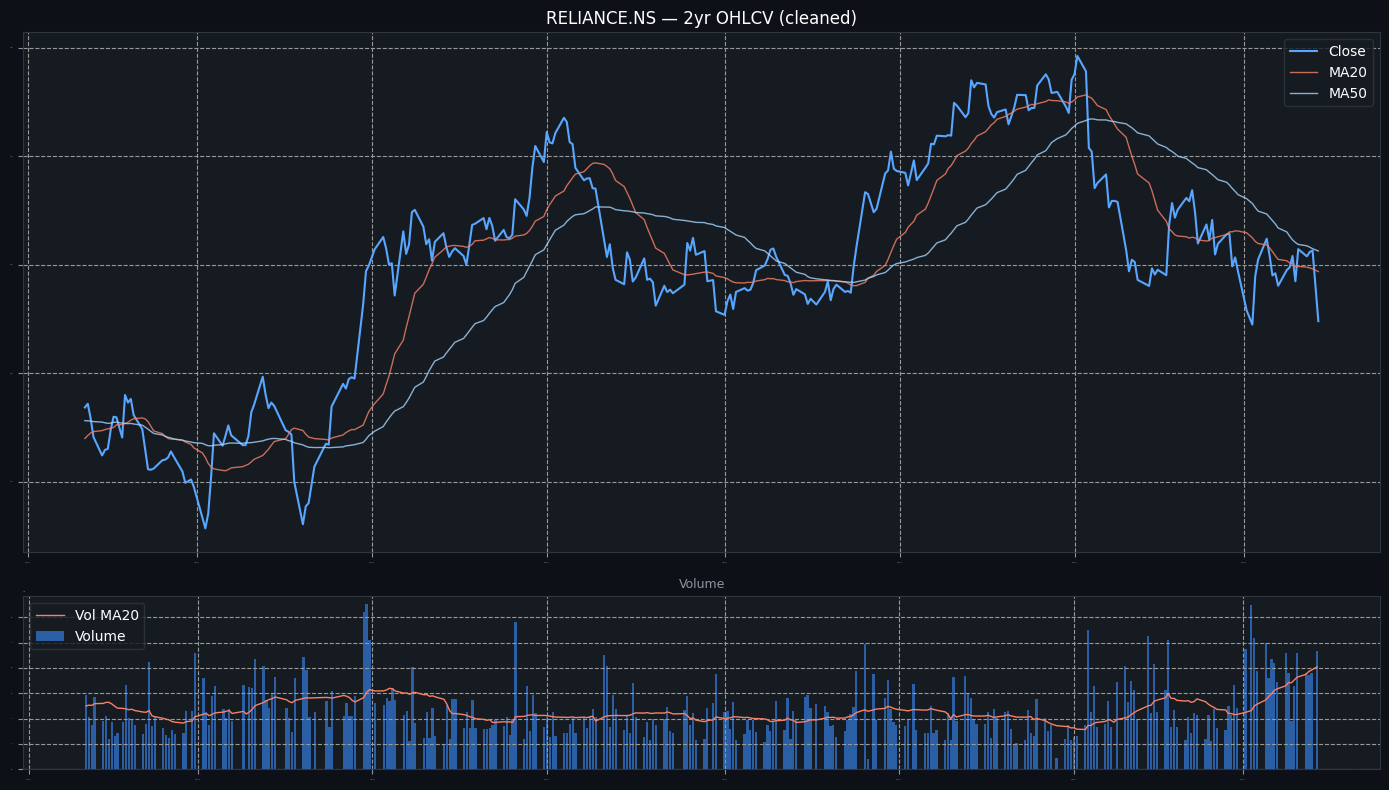

data ingestion complete


In [11]:
# Step 8: Quick visual check - plot a sample stock with MAs

sym = 'RELIANCE.NS'
df = clean_data.get(sym, list(clean_data.values())[0])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={'height_ratios': [3, 1]})
fig.patch.set_facecolor('#0D1117')
for a in [ax1, ax2]:
    a.set_facecolor('#161B22')
    a.tick_params(colors='#8B949E')
    for spine in a.spines.values():
        spine.set_edgecolor('#30363D')

ax1.plot(df.index, df['close'], color='#58A6FF', lw=1.5, label='Close')
ax1.plot(df.index, df['ma20'],  color='#F78166', lw=1.0, label='MA20', alpha=0.8)
ax1.plot(df.index, df['ma50'],  color='#A5D6FF', lw=1.0, label='MA50', alpha=0.8)
ax1.set_title(f'{sym} — 2yr OHLCV (cleaned)', color='white', fontsize=12)
ax1.legend(facecolor='#161B22', edgecolor='#30363D', labelcolor='white')

ax2.bar(df.index, df['volume'], color='#388BFD', alpha=0.6, label='Volume')
ax2.plot(df.index, df['vol_ma20'], color='#F78166', lw=1.0, label='Vol MA20')
ax2.set_title('Volume', color='#8B949E', fontsize=9)
ax2.legend(facecolor='#161B22', edgecolor='#30363D', labelcolor='white')

plt.tight_layout()
plt.savefig('ps6_data/sample_ohlcv.jpg', dpi=120, facecolor='#0D1117')
plt.show()
print('data ingestion complete')